In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
df=pd.read_csv('D:/AML-Lab/Datasets/income_data.csv')
df

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
...,...,...,...
493,494,5.249209,4.568705
494,495,3.471799,2.535002
495,496,6.087610,4.397451
496,497,3.440847,2.070664


In [3]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   Unnamed: 0    income  happiness
0           1  3.862647   2.314489
1           2  4.979381   3.433490
2           3  4.923957   4.599373
3           4  3.214372   2.791114
4           5  7.196409   5.596398
<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  498 non-null    int64  
 1   income      498 non-null    float64
 2   happiness   498 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
None
Unnamed: 0    0
income        0
happiness     0
dtype: int64


In [4]:
df.isnull().sum()

Unnamed: 0    0
income        0
happiness     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [11]:
X = df[["income"]]
y = df["happiness"]

In [12]:
print(X)

       income
0    3.862647
1    4.979381
2    4.923957
3    3.214372
4    7.196409
..        ...
493  5.249209
494  3.471799
495  6.087610
496  3.440847
497  4.530545

[498 rows x 1 columns]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Coefficient:", model.coef_)
print("Model Intercept:", model.intercept_)
print("Model Slope:", model.coef_[0])

Model Coefficient: [0.7247687]
Model Intercept: 0.14170387227353531
Model Slope: 0.7247687016076183


In [15]:
X_train

,income
56,6.029214
227,7.300903
280,3.354252
485,6.101565
220,5.853906
...,...
106,7.176400
270,3.859892
348,5.693725
435,5.754941


In [16]:
X_test

,income
487,4.243873
73,2.864664
231,4.223554
175,2.274523
237,2.210696
...,...
247,5.964058
383,4.851314
19,1.994275
321,4.800344


In [17]:
predictions = model.predict(X_test)
print("Predictions:", predictions)

Predictions: [3.21752987 2.21792257 3.20280332 1.79020704 1.74394749 2.39018719
 4.44664262 4.86010664 1.89050708 3.50456863 4.09833273 2.4318678
 2.85594355 3.54519132 2.78796716 1.80768864 2.52124048 5.16673969
 2.45094439 3.996441   1.83486036 2.72998006 2.63135811 1.23340488
 4.61112137 1.72884986 2.46409207 5.3782968  4.21884267 4.12789401
 1.34529138 3.72063824 2.83545189 3.71043375 4.0008309  4.01012804
 1.2713695  2.47646914 1.31859325 2.24910091 5.35598486 4.42244764
 5.0893214  4.83614181 2.94122983 2.15161714 1.6263909  3.1687238
 2.67722482 1.46401227 4.0291672  2.98869745 5.14038236 3.7164133
 3.58847209 3.3425148  3.54804131 3.94616611 4.93059286 3.81954393
 4.89818897 1.55970378 5.09603988 2.34495858 2.2134292  5.38998089
 4.72238072 3.7692388  2.40771063 5.32646295 4.52828042 3.42736682
 3.04261746 3.07258943 1.94085637 3.12886027 5.11336675 5.38052427
 2.69307466 4.2524758  4.26288758 1.61430179 2.70763229 3.93796482
 3.18066442 1.73248554 3.64552379 4.26950719 2.98446

In [18]:
new_data = pd.DataFrame({'income': [50000, 100000, 150000]})
new_predictions = model.predict(new_data)



In [20]:
print("Predictions for new data:", new_predictions)

Predictions for new data: [ 36238.57678425  72477.01186463 108715.44694502]


In [21]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(398, 1) (100, 1) (398,) (100,)


In [22]:
#Print all Imp Metrics
mae=mean_absolute_error(y_test, predictions)
mse=mean_squared_error(y_test, predictions)
rmse=np.sqrt(mse)
r2=r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 0.6269683431894553
Mean Squared Error: 0.590146394343082
Root Mean Squared Error: 0.768209863476825
R-squared: 0.6662585264303965


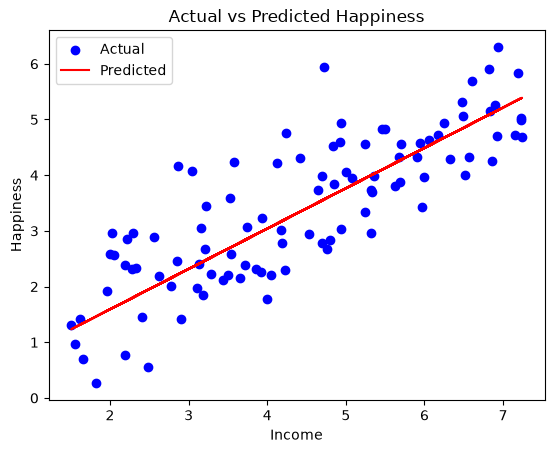

In [24]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, predictions, color='red', label='Predicted')
plt.title('Actual vs Predicted Happiness')
plt.xlabel('Income')
plt.ylabel('Happiness')
plt.legend()
plt.show()

C:\Users\MSIS\AppData\Local\Temp\ipykernel_20176\2394509379.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


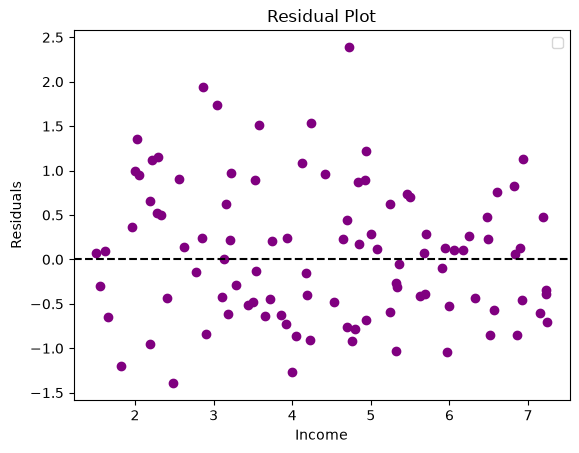

In [26]:
#Make a Residual Plot

residuals = y_test - predictions
plt.scatter(X_test, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Income')
plt.ylabel('Residuals')
plt.legend()
plt.show()

In [ ]:
######COMPLETE #######